<a href="https://colab.research.google.com/github/Thaer-F-Ali/numerical_data_stats_visualizing_normalizing/blob/main/numerical_data_stats.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#@title Copyright 2023 Google LLC. Double-click for license information.
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Colabs

Machine Learning Crash Course uses Colaboratories (Colabs) for all programming exercises. Colab is Google's implementation of [Jupyter Notebook](https://jupyter.org/). For more information about Colabs and how to use them, go to [Welcome to Colaboratory](https://research.google.com/colaboratory).

# Numerical data: Statistics on a dataset

This Colab programming exercise (first of two) is part of the Machine Learning Crash Course module [Working with numerical data](https://developers.google.com/machine-learning/crash-course/numerical-data).

## What to expect

In the section, [First steps with numerical data](https://developers.google.com/machine-learning/crash-course/numerical-data/first-steps), you learned how to do the following:
- Visualize your data in plots or graphs.
- Evaluate potential features and labels mathematically.
- Find [**outliers**](https://developers.google.com/machine-learning/glossary/#outliers) in the dataset.

This exercise takes you through the process of finding columns that contain blatant outliers, which you can then decide to keep in or delete from the dataset.

In [29]:
import sys
!pip uninstall -y pandas
!pip uninstall -y egeaML

Found existing installation: pandas 2.2.2
Uninstalling pandas-2.2.2:
  Successfully uninstalled pandas-2.2.2


In [3]:
# @title Setup - Import relevant modules

# The following code imports relevant modules that
# allow you to run the colab.
# If you encounter technical issues running some of the code sections
# that follow, try running this section again.

import pandas as pd

# The following lines adjust the granularity of reporting.
pd.options.display.max_rows = 10
pd.options.display.float_format = "{:.1f}".format

In [4]:
#@title Import the dataset

# The following code imports the dataset that is used in the colab.

training_df = pd.read_csv(filepath_or_buffer="https://download.mlcc.google.com/mledu-datasets/california_housing_train.csv")

## Get basic statistics

In the following code section, the DataFrame `describe` method returns basic statistics on all the columns in the dataset, such as:

* `count` is the number of populated elements in this column. Ideally, every column contains the same value for `count`, but that's not always the case.
* `mean` is the traditional average of values in that column. We recommend comparing the `mean` to the median for each column. The **median** is the 50% row of the table.
* `std` is the standard deviation of the values in this column.
* `min`, `25%`, `50%`, `75%`, and `max` indicate values in the 0, 25, 50, 75, and 100th percentiles.

In [5]:
# Get statistics on the dataset.

# The following code returns basic statistics about the data in the dataframe.

training_df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.0,17000.0,17000.0,17000.0,17000.0,17000.0,17000.0,17000.0,17000.0
mean,-119.6,35.6,28.6,2643.7,539.4,1429.6,501.2,3.9,207300.9
std,2.0,2.1,12.6,2179.9,421.5,1147.9,384.5,1.9,115983.8
min,-124.3,32.5,1.0,2.0,1.0,3.0,1.0,0.5,14999.0
25%,-121.8,33.9,18.0,1462.0,297.0,790.0,282.0,2.6,119400.0
50%,-118.5,34.2,29.0,2127.0,434.0,1167.0,409.0,3.5,180400.0
75%,-118.0,37.7,37.0,3151.2,648.2,1721.0,605.2,4.8,265000.0
max,-114.3,42.0,52.0,37937.0,6445.0,35682.0,6082.0,15.0,500001.0


### Task: Identify possible outliers

Based on the preceding statisics, do you see any columns that might contain outliers?

In [6]:
# @title Solution (run this code block to view) { display-mode: "form" }

print("""The following columns might contain outliers:

  * total_rooms
  * total_bedrooms
  * population
  * households
  * possibly, median_income

In all of those columns:

  * the standard deviation is almost as high as the mean
  * the delta between 75% and max is much higher than the
      delta between min and 25%.""")

The following columns might contain outliers:

  * total_rooms
  * total_bedrooms
  * population
  * households
  * possibly, median_income

In all of those columns:

  * the standard deviation is almost as high as the mean
  * the delta between 75% and max is much higher than the
      delta between min and 25%.


# Vistualizing data

> Add blockquote



In [7]:
import matplotlib.pyplot as plt
import numpy as np

plt.close("all")

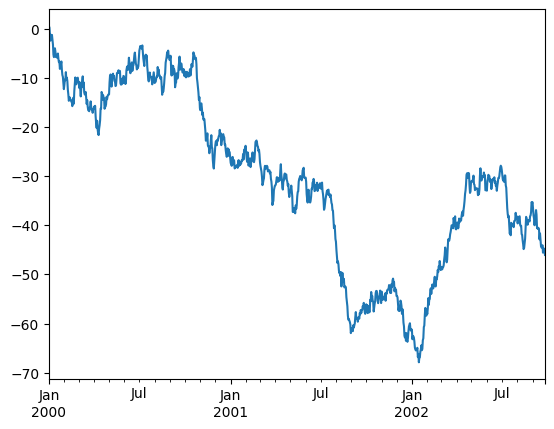

In [8]:
np.random.seed(123456)

ts = pd.Series(np.random.randn(1000), index=pd.date_range("1/1/2000", periods=1000))

ts = ts.cumsum()

ts.plot();

In [9]:
house = training_df[['population', 'median_income']]

In [10]:
house

,population,median_income
0,1015.0,1.5
1,1129.0,1.8
2,333.0,1.7
3,515.0,3.2
4,624.0,1.9
...,...,...
16995,907.0,2.4
16996,1194.0,2.5
16997,1244.0,3.0
16998,1298.0,2.0


In [11]:
house.describe()

,population,median_income
count,17000.0,17000.0
mean,1429.6,3.9
std,1147.9,1.9
min,3.0,0.5
25%,790.0,2.6
50%,1167.0,3.5
75%,1721.0,4.8
max,35682.0,15.0


In [12]:
housePlost = house.cumsum()

<Axes: >

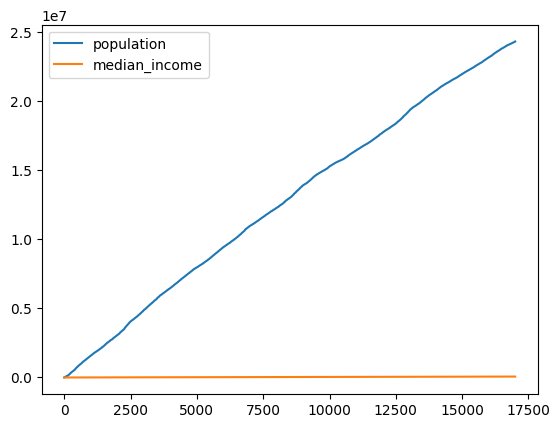

In [13]:
housePlost.plot()

In [14]:
# Noramizing data
from sklearn.preprocessing import MinMaxScaler

In [15]:
noramlizedHousePlot = MinMaxScaler().fit_transform(house)

In [16]:
noramlizedHousePlot = pd.DataFrame(noramlizedHousePlot, columns=['population', 'median_income'])

In [17]:
noramlizedHousePlot.describe()

,population,median_income
count,17000.0,17000.0
mean,0.0,0.2
std,0.0,0.1
min,0.0,0.0
25%,0.0,0.1
50%,0.0,0.2
75%,0.0,0.3
max,1.0,1.0


<Axes: xlabel='median_income', ylabel='population'>

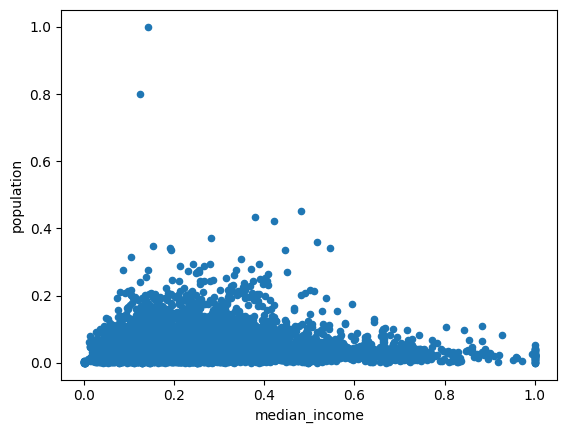

In [18]:
noramlizedHousePlot.plot.scatter(x= "median_income", y ="population" )

In [19]:
logScalledFetures = np.log(house)

<Axes: xlabel='median_income', ylabel='population'>

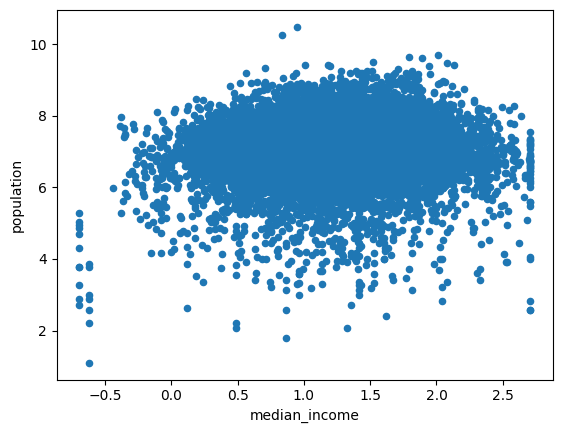

In [20]:
logScalledFetures.plot.scatter( x= "median_income", y ="population")

In [21]:
logScalledFetures.clip(0,2)

,population,median_income
0,2.0,0.4
1,2.0,0.6
2,2.0,0.5
3,2.0,1.2
4,2.0,0.7
...,...,...
16995,2.0,0.9
16996,2.0,0.9
16997,2.0,1.1
16998,2.0,0.7


<Axes: xlabel='median_income', ylabel='population'>

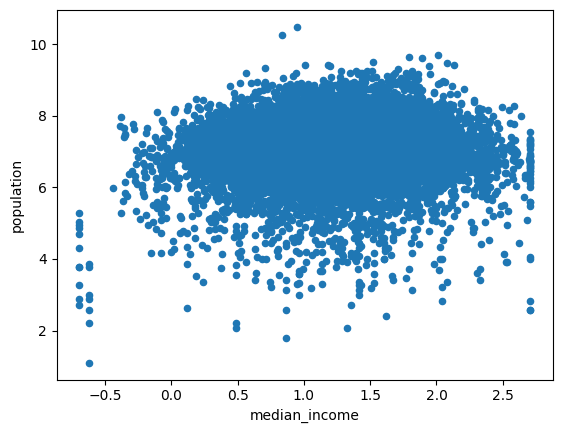

In [22]:
logScalledFetures.plot.scatter( x= "median_income", y ="population")

In [23]:
logScalledFetures.clip(-2,-0.5)

,population,median_income
0,-0.5,-0.5
1,-0.5,-0.5
2,-0.5,-0.5
3,-0.5,-0.5
4,-0.5,-0.5
...,...,...
16995,-0.5,-0.5
16996,-0.5,-0.5
16997,-0.5,-0.5
16998,-0.5,-0.5


<Axes: xlabel='median_income', ylabel='population'>

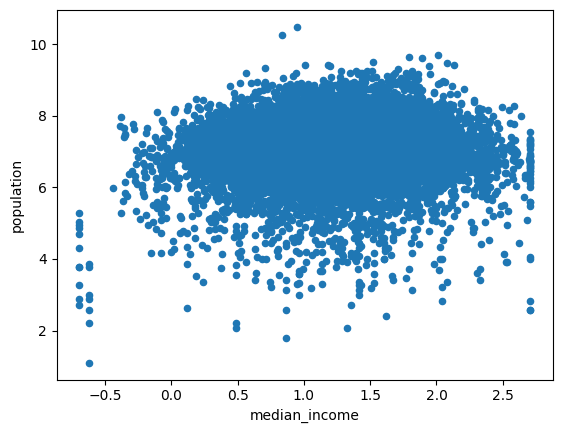

In [24]:
logScalledFetures.plot.scatter( x= "median_income", y ="population")

# KNearestNeighbour Machine learning model

Here, we will apply KNearestNeighphour ML model from **Applies ML With Python** book.

This model is the simple supervised model which can be used for classical regression tasks

In [32]:
# This cell was removed because pandas==1.5.3 was incompatible with the current environment.

In [33]:
!pip install egeaML

  Using cached egeaML-1.0.2.tar.gz (13 kB)
  Preparing metadata (setup.py) ... done
  Using cached pandas-1.5.3.tar.gz (5.2 MB)
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [26]:
#impoting libraries
from egeaML import *

ModuleNotFoundError: No module named 'egeaML'